## STQD6324 Data Management Final Project
### Title: Predicting Online Shopping Purchase Intention Using PySpark

### Matrix: P161449


**Dataset Selection & Problem Relevance**

Finance and business industry is selected as the main topic of this project. The Online Shoppers Purchasing Intention Dataset was selected because it addresses a real-world business problem in the e-commerce industry, which is to predict whether a customer's online browsing session will result in a completed purchase. Accurately identifying customers with high purchasing intention enables businesses to improve marketing effectiveness, optimize website design, enhance customer experiences, and increase sales conversion rates. As online retail continues to grow, understanding customer browsing behaviour has become increasingly important for supporting data-driven decision-making and personalized marketing strategies.

The dataset was obtained from the **UCI Machine Learning Repository**, a widely recognized repository that provides high-quality datasets for research and educational purposes. It contains anonymized online shopping session data collected from an e-commerce website over a one-year period. Each record represents a unique customer browsing session and includes information available at the end of the session, allowing machine learning models to predict whether the session resulted in a completed purchase (*Revenue = True*) or not (*Revenue = False*).


In [1]:
# Import Libraries

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("Online Shopping Intention") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()


## 1. Data Understanding and Preprocessing 
The dataset is highly relevant and sufficiently complex for predictive analytics because it contains 12,330 customer sessions described by 18 behavioural, demographic, and website interaction variables. These variables include administrative page visits, informational page visits, product-related browsing behaviour, browsing duration, bounce rates, exit rates, page values, visitor type, traffic source, operating system, browser, region, and purchase outcome. The combination of numerical, categorical, and Boolean variables provides a comprehensive representation of customer behaviour, making the dataset well suited for exploratory data analysis, feature engineering, and machine learning classification.

The data quality assessment revealed that the dataset contained no missing values, indicating that the customer behaviour information was completely recorded. Duplicate shopping sessions were identified and removed to prevent redundant observations from influencing the analytical results.

In [64]:
# Load Dataset
df = spark.read.csv(
    "online_shoppers_intention.csv",
    header=True,
    inferSchema=True)

In [65]:
# Dataset Information
print("Number of Rows :", df.count())
print("Number of Columns :", len(df.columns))
print(df.printSchema())
print(df.show())
df.describe().show()

Number of Rows : 12330
Number of Columns : 18
root
 |-- Administrative: integer (nullable = true)
 |-- Administrative_Duration: double (nullable = true)
 |-- Informational: integer (nullable = true)
 |-- Informational_Duration: double (nullable = true)
 |-- ProductRelated: integer (nullable = true)
 |-- ProductRelated_Duration: double (nullable = true)
 |-- BounceRates: double (nullable = true)
 |-- ExitRates: double (nullable = true)
 |-- PageValues: double (nullable = true)
 |-- SpecialDay: double (nullable = true)
 |-- Month: string (nullable = true)
 |-- OperatingSystems: integer (nullable = true)
 |-- Browser: integer (nullable = true)
 |-- Region: integer (nullable = true)
 |-- TrafficType: integer (nullable = true)
 |-- VisitorType: string (nullable = true)
 |-- Weekend: boolean (nullable = true)
 |-- Revenue: boolean (nullable = true)

None
+--------------+-----------------------+-------------+----------------------+--------------+-----------------------+-----------+-----------

In [66]:
# Missing Values
missing = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns])

missing.show(vertical=True)

-RECORD 0----------------------
 Administrative          | 0   
 Administrative_Duration | 0   
 Informational           | 0   
 Informational_Duration  | 0   
 ProductRelated          | 0   
 ProductRelated_Duration | 0   
 BounceRates             | 0   
 ExitRates               | 0   
 PageValues              | 0   
 SpecialDay              | 0   
 Month                   | 0   
 OperatingSystems        | 0   
 Browser                 | 0   
 Region                  | 0   
 TrafficType             | 0   
 VisitorType             | 0   
 Weekend                 | 0   
 Revenue                 | 0   



In [67]:
# Duplications
print("Original Rows :", df.count())
df = df.dropDuplicates()
print("After Removing Duplicates :", df.count())

Original Rows : 12330
After Removing Duplicates : 12205


**Interpretation**:
12,330 original rows, 0 missing records across all 18 features, and 125 duplicate sessions removed (leaving 12,205 clean sessions).

### 1.1 Register Spark SQL Table to show the features Contribution (*Exploratory Data Analysis*)

In [21]:
# Register Temp View
df.createOrReplaceTempView("shopping")

In [22]:
# Spark SQL — Revenue Distribution
spark.sql("""
SELECT Revenue,
COUNT(*) AS Total
FROM shopping GROUP BY Revenue""").show()

+-------+-----+
|Revenue|Total|
+-------+-----+
|   true| 1908|
|  false|10297|
+-------+-----+



No purchase (false): 10,297 sessions

Purchase (true): 1,908 sessions

Overall conversion rate: **15.6%**

**Interpretation**:

The distribution of the target variable indicates that only approximately one in six customer sessions resulted in a completed purchase. This demonstrates that the dataset is highly imbalanced, with non-purchasing sessions representing the majority class. Additional evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC were included to provide a more reliable assessment of model performance.

From a business perspective, the relatively high conversion rate suggests that visitors arriving at the website generally exhibit strong purchasing intent.

In [23]:
# Spark SQL — Visitor Type
spark.sql("""
SELECT VisitorType,
COUNT(*) AS Sessions
FROM shopping GROUP BY VisitorType ORDER BY Sessions DESC
""").show()

+-----------------+--------+
|      VisitorType|Sessions|
+-----------------+--------+
|Returning_Visitor|   10431|
|      New_Visitor|    1693|
|            Other|      81|
+-----------------+--------+



Returning Visitors: 10,431

New Visitors: 1,693

Other Visitors: 81

**Interpretation**:

Over 85% of total traffic consists of returning customers.This indicates that customer loyalty and retention are significant strengths of the business, as many users repeatedly return to browse or purchase products.

Conversely, the small proportion of new visitors suggests that customer acquisition efforts may be less effective than retention strategies. Increasing investment in search engine optimization, digital advertising, and social media campaigns could help attract more first-time visitors while maintaining the existing loyal customer.


In [24]:
# Spark SQL — Monthly Purchases
spark.sql("""
SELECT Month,
COUNT(*) AS TotalSessions,
SUM(
CASE WHEN Revenue=True THEN 1 ELSE 0
END
) AS Purchases
FROM shopping GROUP BY Month ORDER BY Purchases DESC
""").show()

+-----+-------------+---------+
|Month|TotalSessions|Purchases|
+-----+-------------+---------+
|  Nov|         2982|      760|
|  May|         3329|      365|
|  Dec|         1706|      216|
|  Mar|         1860|      192|
|  Oct|          549|      115|
|  Sep|          448|       86|
|  Aug|          433|       76|
|  Jul|          432|       66|
| June|          285|       29|
|  Feb|          181|        3|
+-----+-------------+---------+



November: Highest conversion rate (**25.5%**)

May: Highest traffic volume (**3329 sessions**)

February: Lowest sales activity (**3 purchase**)

**Interpretation**:

Shopping activity varies considerably across different months, demonstrating clear seasonal purchasing behaviour. November generated the highest conversion rate despite not having the largest number of sessions, indicating that customers visiting during this period have stronger purchase intentions. This trend is likely influenced by major promotional events such as Black Friday, Cyber Monday, and year-end sales.

Although May has the highest traffic volume, its conversion rate was substantially lower than November, suggesting that many visitors were browsing products without completing purchases. This represents an opportunity to improve remarketing strategies by targeting these potential customers through personalized advertisements or promotional offers. Meanwhile, the sharp decline in February may reflect typical post-holiday purchasing behaviour, as both customer traffic and purchasing activity decrease in February.

In [25]:
# Spark SQL — Weekend Purchases
spark.sql("""
SELECT Weekend, Revenue,
COUNT(*) AS Sessions
FROM shopping GROUP BY Weekend, Revenue
ORDER BY Weekend
""").show()

+-------+-------+--------+
|Weekend|Revenue|Sessions|
+-------+-------+--------+
|  false|   true|    1409|
|  false|  false|    7937|
|   true|  false|    2360|
|   true|   true|     499|
+-------+-------+--------+



Weekday conversion rate: **15.1%**

Weekend conversion rate: **17.5%**

**Interpretation**:

Although weekday shopping sessions account for the majority of website traffic, weekend visitors exhibit a higher purchase conversion rate. This suggests that customers have more available time during weekends to compare products, evaluate alternatives, and complete purchases.

From a business perspective, this finding indicates that weekend-specific promotional campaigns, flash sales, or free shipping offers could generate additional revenue by leveraging customers' increased purchasing intention during weekends.


In [26]:
# Spark SQL — Bounce Rate
spark.sql("""
SELECT Revenue,
AVG(BounceRates) AS AvgBounce,
AVG(ExitRates) AS AvgExit
FROM shopping GROUP BY Revenue
""").show()

+-------+--------------------+--------------------+
|Revenue|           AvgBounce|             AvgExit|
+-------+--------------------+--------------------+
|   true|0.005117152640461205| 0.01955516825681339|
|  false|0.023196678058269193|0.045525525437213984|
+-------+--------------------+--------------------+



Purchasing Sessions: Average Bounce Rate = 0.51% | Average Exit Rate = 1.96%

Non-Purchasing Sessions: Average Bounce Rate = 2.32% | Average Exit Rate = 4.55%

**Interpretation**:

Customers who completed purchases consistently exhibited substantially lower bounce and exit rates than those who did not purchase. Non-purchasing visitors were more likely to leave the website shortly after arriving or exit before completing the purchasing process.

These behavioural indicators suggest that website usability, navigation quality, page loading speed, checkout complexity, or unexpected costs may affect customer patience. Reducing bounce and exit rates through improved website design and user experience could significantly increase overall conversion rates.


In [27]:
# Spark SQL — Average Product Pages
spark.sql("""
SELECT Revenue,
AVG(ProductRelated) AS AvgProductPages,
AVG(ProductRelated_Duration) AS AvgDuration
FROM shopping GROUP BY Revenue
""").show()

+-------+-----------------+------------------+
|Revenue|  AvgProductPages|       AvgDuration|
+-------+-----------------+------------------+
|   true| 48.2101677148847|1876.2096148889038|
|  false|29.05040303000874|1082.9768813254016|
+-------+-----------------+------------------+



Purchasing Customers: Average Product Pages= **48** | Average Browsing Duration= **31 minutes**

Non-Purchasing Customers: Average Product Pages= **29** | Average Browsing Duration= **18 minutes**

**Interpretation**:

Customers who ultimately completed purchases viewed more product pages and spent longer browsing time on the website than non-purchasing visitors. This indicates that purchase decisions are strongly associated with customer engagement and product exploration.

These findings suggest that increasing customer engagement through personalized product recommendations, interactive content, or intelligent recommendation systems could encourage visitors to spend more time browsing and increase the likelihood of completing purchases.


### 1.2 Data Exploratory Visualization

In [28]:
# Convert for plotting
df_p = df.toPandas()

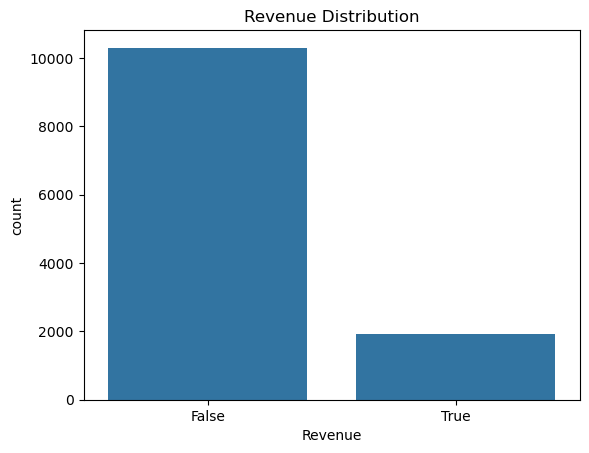

In [31]:
sns.countplot(
    data=df_p,
    x="Revenue"
)
plt.title("Revenue Distribution")
plt.show()

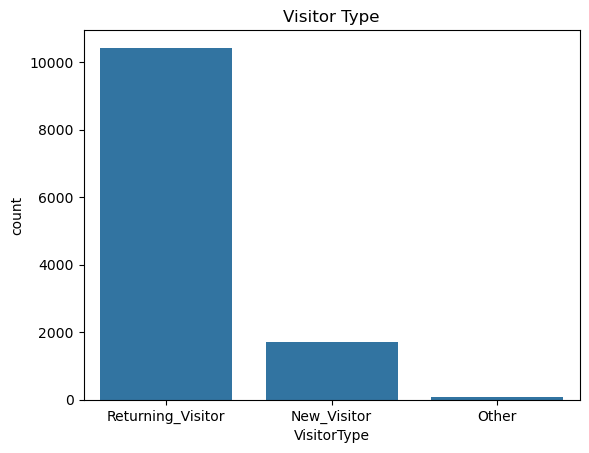

In [33]:
sns.countplot(
    data=df_p,
    x="VisitorType"
)
plt.title("Visitor Type")
plt.show()

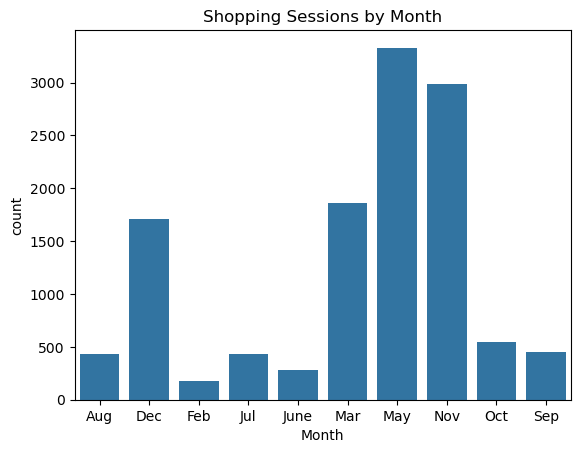

In [116]:
sns.countplot(
    data=df_p,
    x="Month",
    order=sorted(df_p["Month"].unique())
)
plt.title("Shopping Sessions by Month")
plt.show()

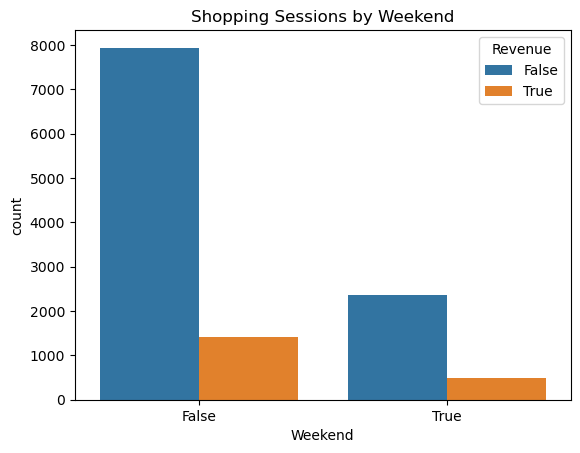

In [119]:
sns.countplot(
    data=df_p,
    x="Weekend",
    hue="Revenue"
)
plt.title("Shopping Sessions by Weekend")
plt.show()

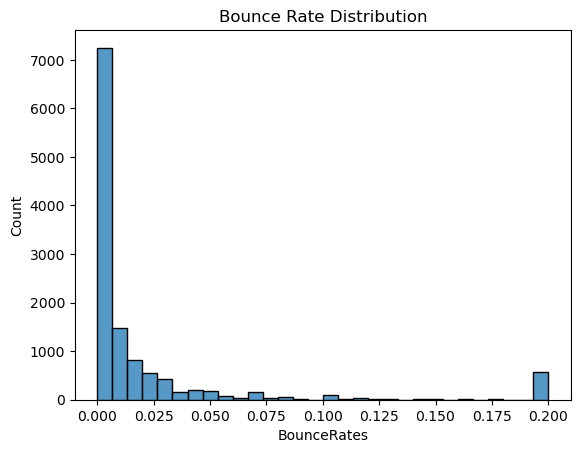

In [36]:
sns.histplot(
    df_p["BounceRates"],
    bins=30
)
plt.title("Bounce Rate Distribution")
plt.show()

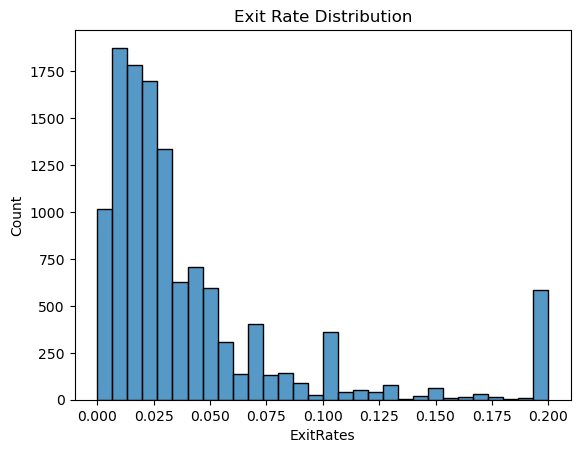

In [37]:
sns.histplot(
    df_p["ExitRates"],
    bins=30
)
plt.title("Exit Rate Distribution")
plt.show()

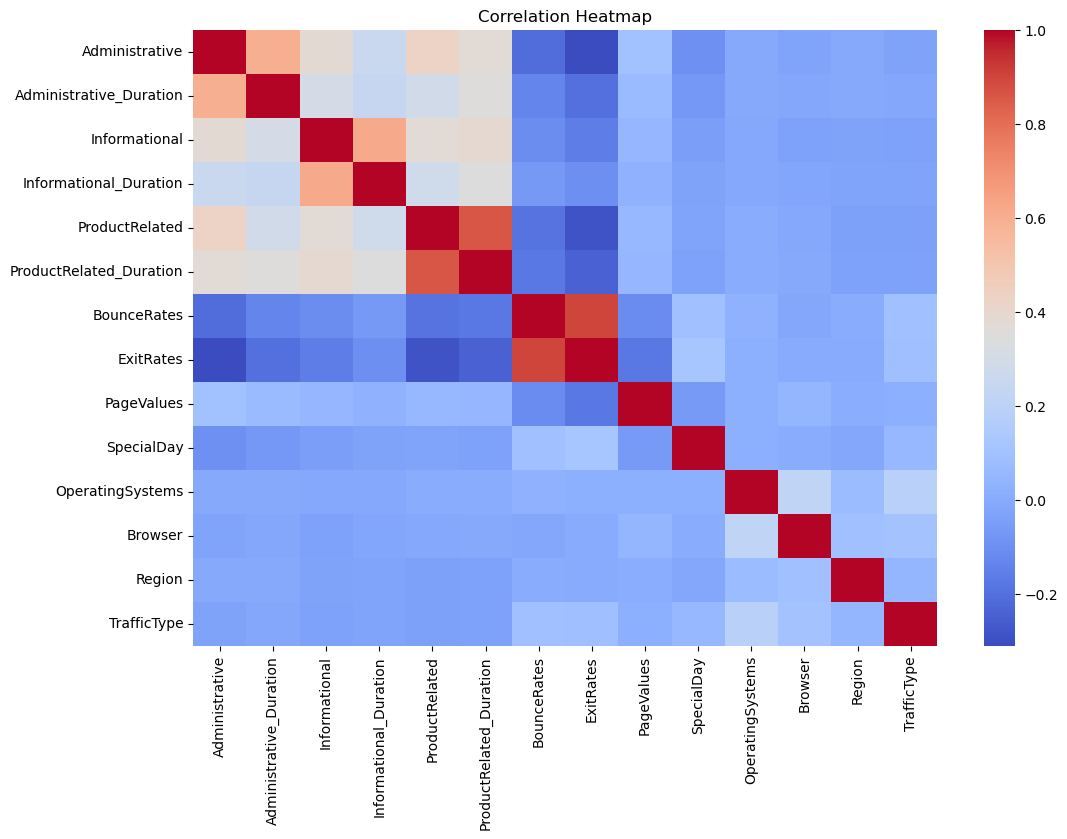

In [40]:
numeric = df_p.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

**Interpretation**:

The correlation heatmap reveals the relationships among the numerical variables describing customer browsing behaviour. Most variables exhibit weak to moderate correlations, indicating that they provide distinct information for predicting purchase intention and that severe multicollinearity is not present.

The strongest positive correlations are observed between ProductRelated and ProductRelated_Duration (0.86), suggesting that customers who visit more product pages naturally spend more time exploring products. Similarly, BounceRates and ExitRates (0.91) are highly correlated, indicating that users who leave a page quickly are also more likely to exit the website without completing a purchase. Moderate correlations between product-related activities and administrative or informational pages further suggest that engaged shoppers often seek additional product or store information before making purchasing decisions. In contrast, SpecialDay exhibits little correlation with other variables, implying that proximity to holidays has minimal influence on customer browsing behaviour compared with real-time engagement metrics.

Overall, the heatmap indicates that customer browsing behaviour, particularly product exploration, engagement duration, and page exit patterns, plays a much more significant role in predicting purchasing intention than calendar-based factors. These findings support the use of behavioural features as key predictors in the machine learning models.

## 2. Machine Learning Models Implication
### 2.1 Data Preprocessing (data transformation and encoding)
Categorical and Boolean variables were transformed into numerical representations to ensure compatibility with Apache Spark ML algorithms.

In [68]:
# Convert boolean features to string features
# Revenue
df = df.withColumn(
    "label",
    when(col("Revenue") == True, 1).otherwise(0)
)
df.select("Revenue", "label").show(10)

+-------+-----+
|Revenue|label|
+-------+-----+
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
|  false|    0|
+-------+-----+
only showing top 10 rows


In [69]:
# Weekend
df = df.withColumn(
    "Weekend",
    when(col("Weekend") == True, 1).otherwise(0))

In [70]:
from pyspark.ml.feature import StringIndexer

# Encode Month
month_indexer = StringIndexer(
    inputCol="Month",
    outputCol="Month_Index",
    handleInvalid="keep")

df = month_indexer.fit(df).transform(df)

In [71]:
# Encode Visitor Type
visitor_indexer = StringIndexer(
    inputCol="VisitorType",
    outputCol="VisitorType_Index",
    handleInvalid="keep")

df = visitor_indexer.fit(df).transform(df)

In [72]:
# Drop Original Columns
df = df.drop(
    "Revenue",
    "Month",
    "VisitorType")

In [73]:
from pyspark.ml.feature import VectorAssembler

# Assemble Features
assembler = VectorAssembler(

inputCols=[
"Administrative",
"Administrative_Duration",
"Informational",
"Informational_Duration",
"ProductRelated",
"ProductRelated_Duration",
"BounceRates",
"ExitRates",
"PageValues",
"SpecialDay",
"OperatingSystems",
"Browser",
"Region",
"TrafficType",
"Weekend",
"Month_Index",
"VisitorType_Index"
],

outputCol="features"
    
)

df = assembler.transform(df)

In [74]:
# Final Dataset
final_df = df.select(
    "features",
    "label")

final_df.show(5, truncate=False)

+--------------------------------------------------------------------------------------------------+-----+
|features                                                                                          |label|
+--------------------------------------------------------------------------------------------------+-----+
|(17,[4,6,7,10,11,12,13,15],[1.0,0.2,0.2,4.0,1.0,9.0,3.0,9.0])                                     |0    |
|(17,[4,6,7,10,11,12,13,15],[1.0,0.2,0.2,1.0,1.0,4.0,3.0,9.0])                                     |0    |
|(17,[4,6,7,10,11,12,13,15],[2.0,0.2,0.2,3.0,3.0,1.0,3.0,9.0])                                     |0    |
|[1.0,6.0,1.0,0.0,45.0,1582.75,0.043478261,0.050821256,54.17976426,0.4,3.0,2.0,1.0,1.0,0.0,9.0,0.0]|0    |
|[2.0,18.0,0.0,0.0,5.0,298.0,0.0,0.028571429,0.0,0.8,2.0,2.0,8.0,4.0,0.0,9.0,0.0]                  |0    |
+--------------------------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [75]:
# Train-test Split
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=123)

print("Training:", train_df.count())
print("Testing :", test_df.count())

Training: 9726
Testing : 2479


In [76]:
train_df.cache()
test_df.cache()

DataFrame[features: vector, label: int]

In [78]:
# Class Distribution
df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1| 1908|
|    0|10297|
+-----+-----+



**Model Selection**

Three machine learning classification algorithms were selected for this study: **Logistic Regression**, **Decision Tree**, and **Random Forest**. These models were chosen because they represent different classification techniques with varying levels of complexity and interpretability. Evaluating these algorithms enables a comprehensive comparison of their predictive performance and suitability for predicting online shopping purchase intention.

In [79]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator)

### 2.2 Logistic Regression
Logistic Regression was selected as the baseline classification model because it is one of the most widely used supervised learning algorithms for binary classification problems. Since the target variable (Revenue) consists of two classes (purchase and non-purchase), Logistic Regression is suitable to estimate the probability of either a customer will complete a purchase or not.

In [80]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100)

lr_model = lr.fit(train_df)

lr_pred = lr_model.transform(test_df)

### 2.3 Decision Tree
Decision Tree was selected because it can model nonlinear relationships and complex decision rules without requiring assumptions about the underlying data distribution. Unlike Logistic Regression, Decision Trees recursively split the data into homogeneous groups based on feature values, making them capable of capturing interactions among customer behavioural variables.

In [83]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=8,
    seed=123)

dt_model = dt.fit(train_df)

dt_pred = dt_model.transform(test_df)

### 2.4 Random Forest
Random Forest was selected because it is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting.

In [84]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=123)

rf_model = rf.fit(train_df)

rf_pred = rf_model.transform(test_df)

## 3. Model Evaluation

In [88]:
# Accuracy score
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_acc = accuracy.evaluate(lr_pred)
dt_acc = accuracy.evaluate(dt_pred)
rf_acc = accuracy.evaluate(rf_pred)

print("Logistic Regression Accuracy :", lr_acc)
print("Decision Tree Accuracy       :", dt_acc)
print("Random Forest Accuracy       :", rf_acc)

Logistic Regression Accuracy : 0.884263114071607
Decision Tree Accuracy       : 0.8967527060782681
Random Forest Accuracy       : 0.914654454621149


In [89]:
# Precision Score
precision = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

lr_pre = precision.evaluate(lr_pred)
dt_pre = precision.evaluate(dt_pred)
rf_pre = precision.evaluate(rf_pred)

print("Logistic Regression Precision :", lr_pre)
print("Decision Tree Precision       :", dt_pre)
print("Random Forest Precision       :", rf_pre)

Logistic Regression Precision : 0.8742107379909212
Decision Tree Precision       : 0.8916124527736681
Random Forest Precision       : 0.9102382990988553


In [90]:
# Recall Score
recall = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

lr_rec = recall.evaluate(lr_pred)
dt_rec = recall.evaluate(dt_pred)
rf_rec = recall.evaluate(rf_pred)

print("Logistic Regression Recall :", lr_rec)
print("Decision Tree Recall       :", dt_rec)
print("Random Forest Recall       :", rf_rec)

Logistic Regression Recall : 0.884263114071607
Decision Tree Recall       : 0.8967527060782681
Random Forest Recall       : 0.914654454621149


In [92]:
# F1 Score
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

lr_f1 = f1.evaluate(lr_pred)
dt_f1 = f1.evaluate(dt_pred)
rf_f1 = f1.evaluate(rf_pred)

print("Logistic Regression F1 :", lr_f1)
print("Decision Tree F1       :", dt_f1)
print("Random Forest F1       :", rf_f1)

Logistic Regression F1 : 0.866787990689837
Decision Tree F1       : 0.8934378272310776
Random Forest F1       : 0.911174740285114


In [94]:
# ROC-AUC
roc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

lr_auc = roc.evaluate(lr_pred)
dt_auc = roc.evaluate(dt_pred)
rf_auc = roc.evaluate(rf_pred)

print("Logistic Regression ROC :", lr_auc)
print("Decision Tree ROC       :", dt_auc)
print("Random Forest ROC       :", rf_auc)

Logistic Regression ROC : 0.9035215076347899
Decision Tree ROC       : 0.7748465428157358
Random Forest ROC       : 0.945879759929428


In [105]:
# Importance of Features Based on result of Random Forest 
feature_names = [
"Administrative",
"Administrative_Duration",
"Informational",
"Informational_Duration",
"ProductRelated",
"ProductRelated_Duration",
"BounceRates",
"ExitRates",
"PageValues",
"SpecialDay",
"Month",
"VisitorType",
"OperatingSystems",
"Browser",
"Region",
"TrafficType",
"Weekend"]

importance = rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
8,PageValues,0.515337
7,ExitRates,0.068416
15,TrafficType,0.064170
4,ProductRelated,0.053509
5,ProductRelated_Duration,0.053453
0,Administrative,0.045812
6,BounceRates,0.045507
1,Administrative_Duration,0.035258
13,Browser,0.021759
12,OperatingSystems,0.019070


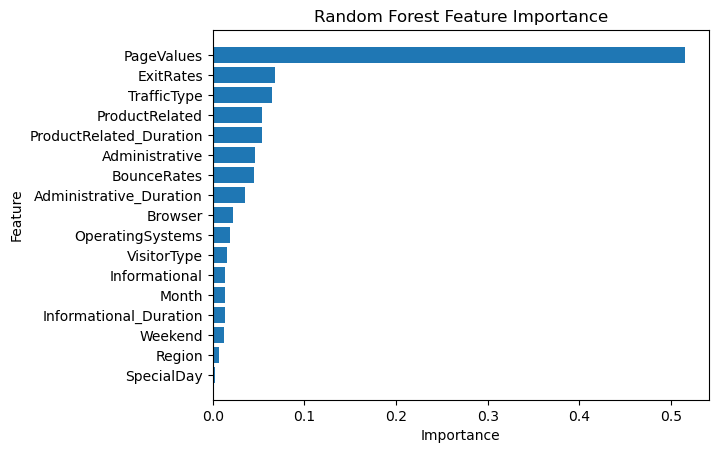

In [108]:
# Importance Visualization
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

|**Top Features**|**Lowest Features**|
|---|---|
|1. PageValues|1. SpecialDay|
|2. ExitRates|2. Region|
|3. TrafficType|3. Weekend|
|4. ProductRelated|4. Informational_Duration|
|5. ProductRelated_Duration|5. Month|

**Interpretation**:

Random Forest computes feature importance by aggregating the reduction in impurity across all trees, making it more stable and generally more informative than a single Decision Tree. Feature importance analysis demonstrates that customer browsing behaviour contributes far more to purchase prediction than demographic characteristics. Among all variables, **PageValues** emerged as the most influential predictor, accounting for more than half of the model's predictive capability. This indicates that visitors who interact with high-value webpages are considerably more likely to complete purchases.

Similarly, ProductRelated pages, browsing duration, and ExitRates were identified as important behavioural indicators of purchasing intention. In contrast, variables such as Region, SpecialDay, and Weekend contributed relatively little to the predictive model. These findings suggest that real-time customer behaviour provides substantially more predictive information than static customer characteristics.

In [113]:
# Model Evaluation Comparison
comparison = pd.DataFrame({
"Model":["Logistic Regression","Decision Tree","Random Forest"],
"Accuracy":[lr_acc,dt_acc,rf_acc],
"Precision":[lr_pre,dt_pre,rf_pre],
"Recall":[lr_rec,dt_rec,rf_rec],
"F1":[lr_f1,dt_f1,rf_f1],
"ROC-AUC":[lr_auc,dt_auc,rf_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.884263,0.874211,0.884263,0.866788,0.903522
1,Decision Tree,0.896753,0.891612,0.896753,0.893438,0.774847
2,Random Forest,0.914654,0.910238,0.914654,0.911175,0.945880


In [112]:
# Best Model Ranking
best = comparison.sort_values(
    by="F1",
    ascending=False)
best

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.914654,0.910238,0.914654,0.911175,0.945880
1,Decision Tree,0.896753,0.891612,0.896753,0.893438,0.774847
0,Logistic Regression,0.884263,0.874211,0.884263,0.866788,0.903522


**Interpretation**:

The comparative evaluation demonstrates that the Random Forest model consistently outperformed Logistic Regression and Decision Tree across all performance metrics. Its superior Accuracy, Precision, Recall, F1-score, and ROC-AUC indicate a stronger ability to distinguish purchasing customers from non-purchasing customers while minimizing classification errors.

The high Precision (91.02%) indicates that when the model predicts a customer will complete a purchase, the prediction is correct in more than nine out of ten cases. This reduces unnecessary marketing costs by minimizing promotional efforts directed toward customers with low purchasing probability.

Furthermore, the ROC-AUC value of 94.59% demonstrates excellent discriminative capability, confirming that the model effectively differentiates between purchasing and non-purchasing sessions despite the underlying class imbalance. Based on these findings, the Random Forest model is the most appropriate choice for deployment in customer relationship management systems or real-time recommendation engines to support personalized marketing, targeted promotions, and conversion optimization.